AbdelRahman Hamdi Hassan 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings

warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('character-predictions.csv')
df.head()

,S.No,actual,pred,alive,plod,name,title,male,culture,dateOfBirth,...,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,boolDeadRelations,isPopular,popularity,isAlive
0,1,0,0,0.054,0.946,Viserys II Targaryen,NaN,1,NaN,NaN,...,0.0,NaN,0,0,NaN,11,1,1,0.605351,0
1,2,1,0,0.387,0.613,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,...,NaN,1.0,1,1,97.0,1,1,1,0.896321,1
2,3,1,0,0.493,0.507,Addison Hill,Ser,1,NaN,NaN,...,NaN,NaN,0,1,NaN,0,0,0,0.267559,1
3,4,0,0,0.076,0.924,Aemma Arryn,Queen,0,NaN,82.0,...,NaN,0.0,1,1,23.0,0,0,0,0.183946,0
4,5,1,1,0.617,0.383,Sylva Santagar,Greenstone,0,Dornish,276.0,...,NaN,1.0,1,1,29.0,0,0,0,0.043478,1


In [4]:
df.shape

(1946, 33)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1946 entries, 0 to 1945
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No               1946 non-null   int64  
 1   actual             1946 non-null   int64  
 2   pred               1946 non-null   int64  
 3   alive              1946 non-null   float64
 4   plod               1946 non-null   float64
 5   name               1946 non-null   object 
 6   title              938 non-null    object 
 7   male               1946 non-null   int64  
 8   culture            677 non-null    object 
 9   dateOfBirth        433 non-null    float64
 10  DateoFdeath        444 non-null    float64
 11  mother             21 non-null     object 
 12  father             26 non-null     object 
 13  heir               23 non-null     object 
 14  house              1519 non-null   object 
 15  spouse             276 non-null    object 
 16  book1              1946 

In [6]:
df.describe().T 

,count,mean,std,min,25%,50%,75%,max
S.No,1946.0,973.500000,561.906131,1.0,487.250000,973.500000,1459.750000,1946.0
actual,1946.0,0.745632,0.435617,0.0,0.000000,1.000000,1.000000,1.0
pred,1946.0,0.687050,0.463813,0.0,0.000000,1.000000,1.000000,1.0
alive,1946.0,0.634470,0.312637,0.0,0.391250,0.735500,0.899000,1.0
plod,1946.0,0.365530,0.312637,0.0,0.101000,0.264500,0.608750,1.0
male,1946.0,0.619219,0.485704,0.0,0.000000,1.000000,1.000000,1.0
dateOfBirth,433.0,1577.364896,19565.414460,-28.0,240.000000,268.000000,285.000000,298299.0
DateoFdeath,444.0,2950.193694,28192.245529,0.0,282.000000,299.000000,299.000000,298299.0
book1,1946.0,0.198356,0.398864,0.0,0.000000,0.000000,0.000000,1.0
book2,1946.0,0.374615,0.484148,0.0,0.000000,0.000000,1.000000,1.0


In [7]:
df.isnull().sum()

S.No                    0
actual                  0
pred                    0
alive                   0
plod                    0
name                    0
title                1008
male                    0
culture              1269
dateOfBirth          1513
DateoFdeath          1502
mother               1925
father               1920
heir                 1923
house                 427
spouse               1670
book1                   0
book2                   0
book3                   0
book4                   0
book5                   0
isAliveMother        1925
isAliveFather        1920
isAliveHeir          1923
isAliveSpouse        1670
isMarried               0
isNoble                 0
age                  1513
numDeadRelations        0
boolDeadRelations       0
isPopular               0
popularity              0
isAlive                 0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df_names = df.columns
df_names

Index(['S.No', 'actual', 'pred', 'alive', 'plod', 'name', 'title', 'male',
       'culture', 'dateOfBirth', 'DateoFdeath', 'mother', 'father', 'heir',
       'house', 'spouse', 'book1', 'book2', 'book3', 'book4', 'book5',
       'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse',
       'isMarried', 'isNoble', 'age', 'numDeadRelations', 'boolDeadRelations',
       'isPopular', 'popularity', 'isAlive'],
      dtype='object')

In [10]:
null_columns = df.columns[df.isnull().any()]
null_columns

Index(['title', 'culture', 'dateOfBirth', 'DateoFdeath', 'mother', 'father',
       'heir', 'house', 'spouse', 'isAliveMother', 'isAliveFather',
       'isAliveHeir', 'isAliveSpouse', 'age'],
      dtype='object')

In [11]:
drop_null = ['S.No','title', 'culture', 'dateOfBirth', 'DateoFdeath', 'mother', 'father',
       'heir', 'spouse', 'isAliveMother', 'isAliveFather',
       'isAliveHeir', 'isAliveSpouse', 'age']
df = df.drop(columns=drop_null)
df.head()

,actual,pred,alive,plod,name,male,house,book1,book2,book3,book4,book5,isMarried,isNoble,numDeadRelations,boolDeadRelations,isPopular,popularity,isAlive
0,0,0,0.054,0.946,Viserys II Targaryen,1,NaN,0,0,0,0,0,0,0,11,1,1,0.605351,0
1,1,0,0.387,0.613,Walder Frey,1,House Frey,1,1,1,1,1,1,1,1,1,1,0.896321,1
2,1,0,0.493,0.507,Addison Hill,1,House Swyft,0,0,0,1,0,0,1,0,0,0,0.267559,1
3,0,0,0.076,0.924,Aemma Arryn,0,House Arryn,0,0,0,0,0,1,1,0,0,0,0.183946,0
4,1,1,0.617,0.383,Sylva Santagar,0,House Santagar,0,0,0,1,0,1,1,0,0,0,0.043478,1


In [12]:
df.shape

(1946, 19)

In [13]:
df.house.value_counts()

Night's Watch      105
House Frey          97
House Stark         72
House Targaryen     62
House Lannister     49
                  ... 
House Gower          1
House Borrell        1
Citadel              1
Wise Masters         1
Three-eyed crow      1
Name: house, Length: 347, dtype: int64

In [14]:
names_with_null_house = df[df['house'].isnull()]['name'].tolist()

print(len (names_with_null_house))

427


In [15]:
df.house.isnull().sum()

427

In [16]:
lastnames = [name.split()[-1] for name in names_with_null_house]
print (len(lastnames))

427


In [17]:
houses = ['House ' + lastname for lastname in lastnames]

df.loc[df['house'].isnull(), 'house'] = houses

In [18]:
df.isnull().sum()

actual               0
pred                 0
alive                0
plod                 0
name                 0
male                 0
house                0
book1                0
book2                0
book3                0
book4                0
book5                0
isMarried            0
isNoble              0
numDeadRelations     0
boolDeadRelations    0
isPopular            0
popularity           0
isAlive              0
dtype: int64

In [19]:
df.house.value_counts()

Night's Watch      105
House Frey          99
House Targaryen     79
House Stark         76
House Lannister     51
                  ... 
House Morne          1
House Frynne         1
House Frenya         1
House Fralegg        1
Three-eyed crow      1
Name: house, Length: 714, dtype: int64

In [20]:
df.head()

,actual,pred,alive,plod,name,male,house,book1,book2,book3,book4,book5,isMarried,isNoble,numDeadRelations,boolDeadRelations,isPopular,popularity,isAlive
0,0,0,0.054,0.946,Viserys II Targaryen,1,House Targaryen,0,0,0,0,0,0,0,11,1,1,0.605351,0
1,1,0,0.387,0.613,Walder Frey,1,House Frey,1,1,1,1,1,1,1,1,1,1,0.896321,1
2,1,0,0.493,0.507,Addison Hill,1,House Swyft,0,0,0,1,0,0,1,0,0,0,0.267559,1
3,0,0,0.076,0.924,Aemma Arryn,0,House Arryn,0,0,0,0,0,1,1,0,0,0,0.183946,0
4,1,1,0.617,0.383,Sylva Santagar,0,House Santagar,0,0,0,1,0,1,1,0,0,0,0.043478,1


In [21]:
len (df['name'].unique())

1946

In [22]:
df = df.drop(columns=['name'])

In [23]:
len (df['house'].unique())

714

In [24]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['house'] = label_encoder.fit_transform(df['house'])
df = pd.DataFrame(df)
df.head()

,actual,pred,alive,plod,male,house,book1,book2,book3,book4,book5,isMarried,isNoble,numDeadRelations,boolDeadRelations,isPopular,popularity,isAlive
0,0,0,0.054,0.946,1,583,0,0,0,0,0,0,0,11,1,1,0.605351,0
1,1,0,0.387,0.613,1,228,1,1,1,1,1,1,1,1,1,1,0.896321,1
2,1,0,0.493,0.507,1,576,0,0,0,1,0,0,1,0,0,0,0.267559,1
3,0,0,0.076,0.924,0,55,0,0,0,0,0,1,1,0,0,0,0.183946,0
4,1,1,0.617,0.383,0,535,0,0,0,1,0,1,1,0,0,0,0.043478,1


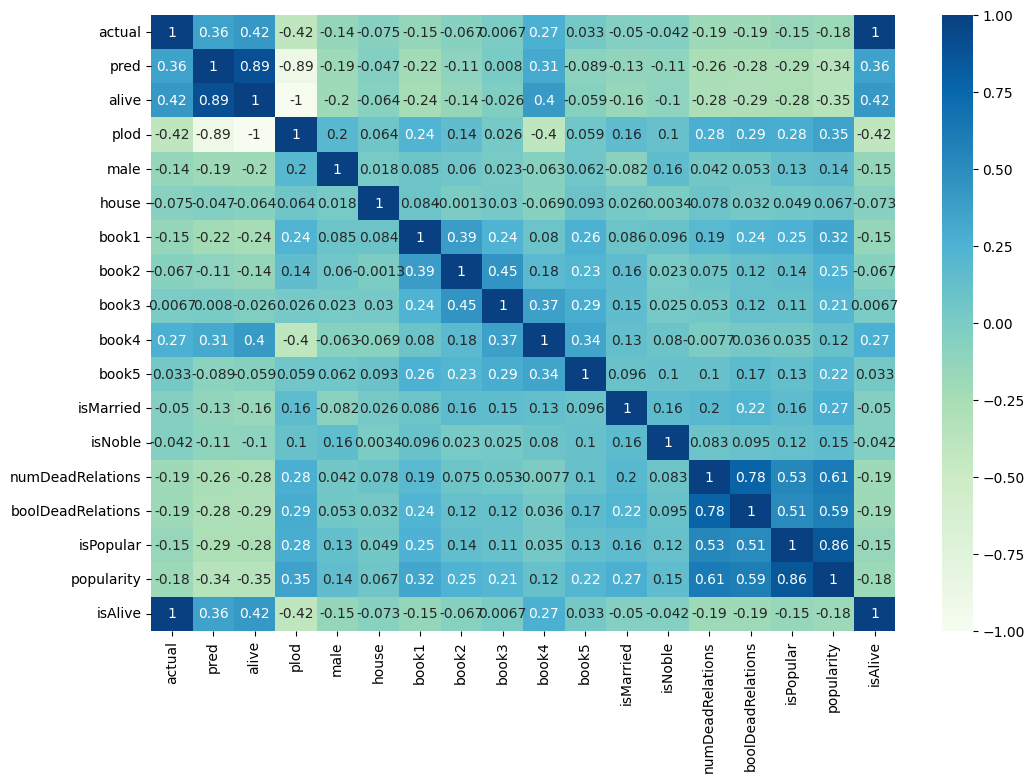

In [25]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='GnBu',annot=True)
plt.show()

In [26]:
df = df.drop(columns=['actual'])

In [27]:
df = df.drop(columns=['book3'])

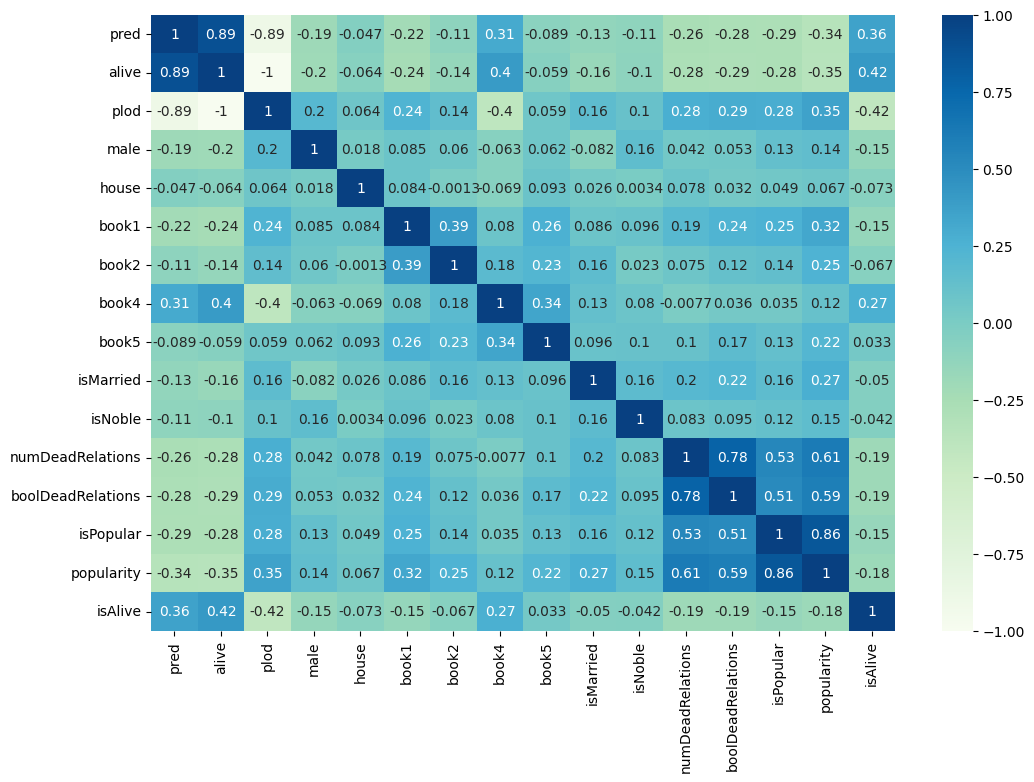

In [28]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='GnBu',annot=True)
plt.show()

In [29]:
X = df.drop(['isAlive'], axis=1)

y = df['isAlive']

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state = 0)

#Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [31]:
X_train.shape

(1751, 15)

In [32]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

In [33]:
classifier = Sequential()

# Adding the input layer and the first hidden layer
classifier.add(Dense(units=64, kernel_initializer='he_uniform', activation='relu', input_dim=X_train.shape[1]))
classifier.add(Dropout(rate=0.3))
classifier.add(BatchNormalization())

# Adding the second hidden layer
classifier.add(Dense(units=32, kernel_initializer='he_uniform', activation='relu'))
classifier.add(Dropout(rate=0.2))
classifier.add(BatchNormalization())

# Adding the third hidden layer
classifier.add(Dense(units=16, kernel_initializer='he_uniform', activation='relu'))
classifier.add(Dropout(rate=0.2))
classifier.add(BatchNormalization())

# Adding the output layer
classifier.add(Dense(units=1, kernel_initializer='glorot_uniform', activation='sigmoid'))


In [34]:
classifier.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                1024      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 batch_normalization (BatchN  (None, 64)               256       
 ormalization)                                                   
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 batch_normalization_1 (Batc  (None, 32)               128       
 hNormalization)                                        

In [35]:
classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [36]:
history=classifier.fit(X_train, y_train,validation_split=0.2, batch_size=32, epochs=180)

Epoch 1/180
44/44 [==============================] - 6s 23ms/step - loss: 0.7839 - accuracy: 0.5464 - val_loss: 0.5835 - val_accuracy: 0.7635
Epoch 2/180
44/44 [==============================] - 0s 8ms/step - loss: 0.6831 - accuracy: 0.6314 - val_loss: 0.5549 - val_accuracy: 0.7749
Epoch 3/180
44/44 [==============================] - 0s 8ms/step - loss: 0.6050 - accuracy: 0.6921 - val_loss: 0.5317 - val_accuracy: 0.7806
Epoch 4/180
44/44 [==============================] - 0s 8ms/step - loss: 0.5849 - accuracy: 0.7164 - val_loss: 0.5150 - val_accuracy: 0.7778
Epoch 5/180
44/44 [==============================] - 0s 9ms/step - loss: 0.5657 - accuracy: 0.7279 - val_loss: 0.5064 - val_accuracy: 0.7892
Epoch 6/180
44/44 [==============================] - 0s 9ms/step - loss: 0.5425 - accuracy: 0.7371 - val_loss: 0.4994 - val_accuracy: 0.7863
Epoch 7/180
44/44 [==============================] - 0s 8ms/step - loss: 0.5338 - accuracy: 0.7429 - val_loss: 0.4937 - val_accuracy: 0.7863
Epoch 8/180


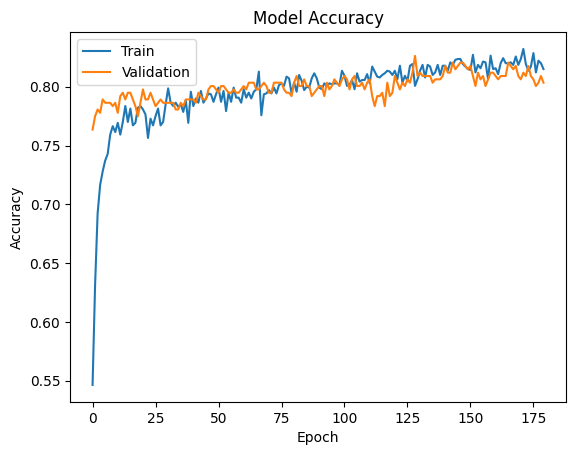

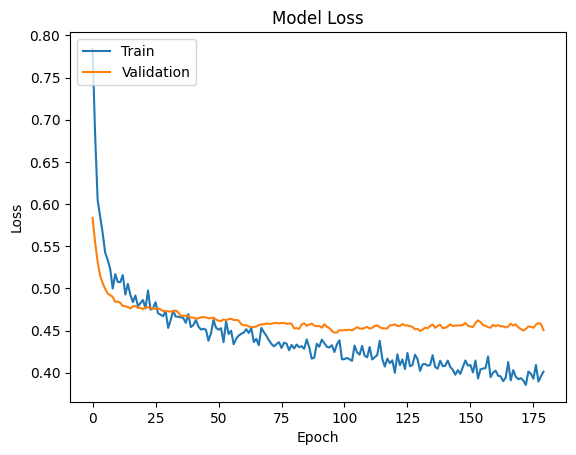

In [37]:

import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history.history['accuracy']) # Access history from the 'history' object
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss']) # Access history from the 'history' object
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [38]:
# Predicting the Test set results
y_pred = classifier.predict(X_test)
y_pred = (y_pred >= 0.5)

7/7 [==============================] - 0s 4ms/step


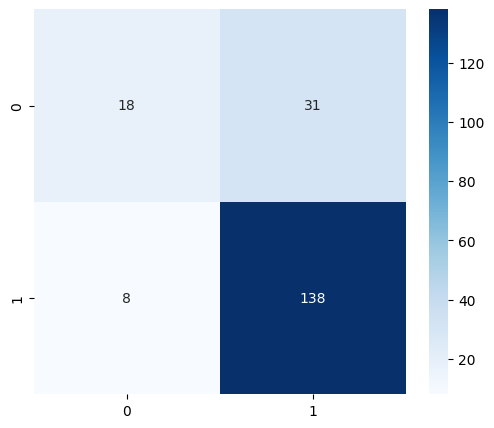

In [39]:
# Confusion matrix with blue colors wiyh 6*5 fig size

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, cmap="Blues", annot=True, fmt='g')
plt.show()


In [40]:
# Classification report

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, digits=4))


              precision    recall  f1-score   support

           0     0.6923    0.3673    0.4800        49
           1     0.8166    0.9452    0.8762       146

    accuracy                         0.8000       195
   macro avg     0.7544    0.6563    0.6781       195
weighted avg     0.7853    0.8000    0.7766       195

